# Penguins

### Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import pandas as pd
from matplotlib import pyplot as plt

data_path = "../data/penguins_size.csv"

penguins = pd.read_csv(data_path).dropna()
adelie = penguins[penguins['species'] == 'Adelie']

print(f"There are {len(adelie)} rows of data.")

adelie.head()

There are 146 rows of data.


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


### Part (a): Explain which Bayesian model is appropriate

For this problem I would say a fitting model to chose would be to use a normal-normal model since the problem deals with biological continuous differences in the same species which very often are normally distributed.

In [2]:
prior_mean = 200
prior_sd = 30

# Check: prior 95% interval covers the plausible range
prior_lower = stats.norm.ppf(0.025, prior_mean, prior_sd)
prior_upper = stats.norm.ppf(0.975, prior_mean, prior_sd)
print(f"Prior: μ ~ N(μ₀={prior_mean}, σ₀²={prior_sd**2})")
print(f"Prior 95% interval: ({prior_lower:.1f}, {prior_upper:.1f}) mm")
print(f"This covers the plausible range (140-260 mm) as requested.")

Prior: μ ~ N(μ₀=200, σ₀²=900)
Prior 95% interval: (141.2, 258.8) mm
This covers the plausible range (140-260 mm) as requested.


### Part (c): Load data and compute Adelie sample statistics

In [3]:
n = len(adelie)
sample_mean = adelie['flipper_length_mm'].mean()
sample_sd = adelie['flipper_length_mm'].std()

print(f"Number of Adelie penguins: {n}")
print(f"Sample mean flipper length: {sample_mean:.2f} mm")
print(f"Sample standard deviation: {sample_sd:.2f} mm")
print()

sigma_sq = sample_sd**2    # Estimated population variance from data
print(f"Estimated population variance (σ²): {sigma_sq:.2f}")

Number of Adelie penguins: 146
Sample mean flipper length: 190.10 mm
Sample standard deviation: 6.52 mm

Estimated population variance (σ²): 42.53


### Part (d): Posterior calculation and 95% credible interval

In [4]:
# Prior precision (1/variance)
prior_precision = 1 / (prior_sd**2)

# Likelihood precision (assuming known variance)
likelihood_precision = n / sigma_sq

# Posterior precision = prior_precision + likelihood_precision
posterior_precision = prior_precision + likelihood_precision
posterior_var = 1 / posterior_precision
posterior_sd = np.sqrt(posterior_var)

# Posterior mean = weighted average of prior mean and sample mean
posterior_mean = (prior_precision * prior_mean + 
                  likelihood_precision * sample_mean) / posterior_precision

print(f"Posterior distribution: μ | data ~ N({posterior_mean:.2f}, {posterior_var:.2f})")
print(f"Posterior mean: {posterior_mean:.2f} mm")
print(f"Posterior standard deviation: {posterior_sd:.2f} mm")
print()

# 95% credible interval (middle)
ci_lower = stats.norm.ppf(0.025, posterior_mean, posterior_sd)
ci_upper = stats.norm.ppf(0.975, posterior_mean, posterior_sd)

print(f"95% Credible Interval for μ: ({ci_lower:.2f}, {ci_upper:.2f}) mm")
print()
print("Interpretation:")
print(f"  Given our prior belief (μ ≈ {prior_mean} ± {prior_sd}) and the observed")
print(f"  data (n={n}, sample mean={sample_mean:.2f} mm), we are 95% confident that")
print(f"  the true population mean flipper length for Adelie penguins lies")
print(f"  between {ci_lower:.1f} and {ci_upper:.1f} mm.")

Posterior distribution: μ | data ~ N(190.11, 0.29)
Posterior mean: 190.11 mm
Posterior standard deviation: 0.54 mm

95% Credible Interval for μ: (189.05, 191.16) mm

Interpretation:
  Given our prior belief (μ ≈ 200 ± 30) and the observed
  data (n=146, sample mean=190.10 mm), we are 95% confident that
  the true population mean flipper length for Adelie penguins lies
  between 189.0 and 191.2 mm.


### Visualization: Prior and Posterior

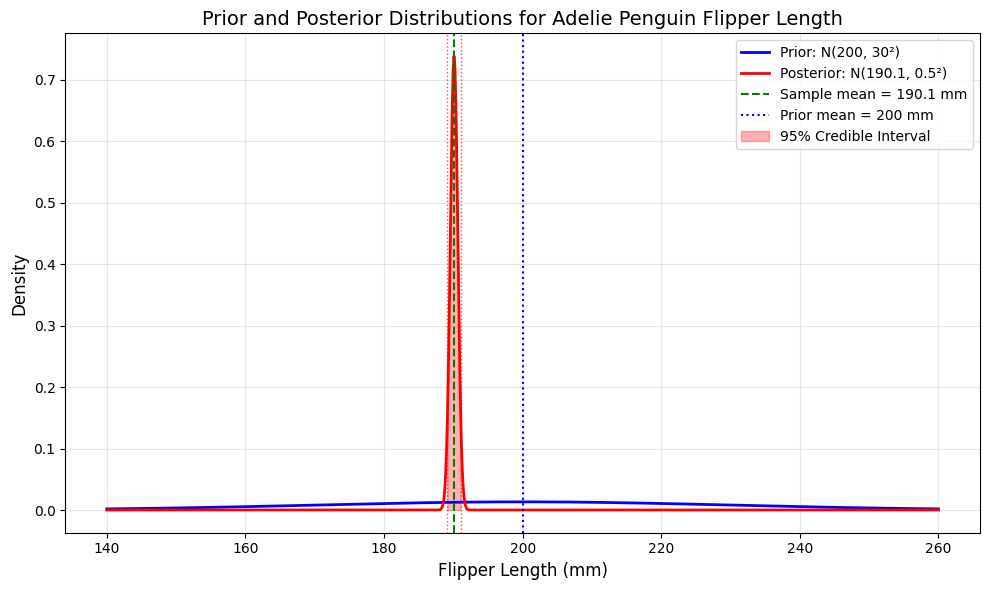

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Prior
x = np.linspace(prior_mean - 2*prior_sd, prior_mean + 2*prior_sd, 1000)
y_prior = stats.norm.pdf(x, prior_mean, prior_sd)
ax.plot(x, y_prior, 'b-', label=f'Prior: N({prior_mean}, {prior_sd}²)', linewidth=2)

# Posterior
y_posterior = stats.norm.pdf(x, posterior_mean, posterior_sd)
ax.plot(x, y_posterior, 'r-', label=f'Posterior: N({posterior_mean:.1f}, {posterior_sd:.1f}²)', linewidth=2)

# Add sample mean line
ax.axvline(sample_mean, color='green', linestyle='--', 
           label=f'Sample mean = {sample_mean:.1f} mm', linewidth=1.5)

# Add prior mean line
ax.axvline(prior_mean, color='blue', linestyle=':', 
           label=f'Prior mean = {prior_mean} mm', linewidth=1.5)

# Add credible interval bounds
ax.axvline(ci_lower, color='red', linestyle=':', alpha=0.7, linewidth=1)
ax.axvline(ci_upper, color='red', linestyle=':', alpha=0.7, linewidth=1)
ax.fill_between(x, 0, y_posterior, where=(x >= ci_lower) & (x <= ci_upper), 
                alpha=0.3, color='red', label='95% Credible Interval')

ax.set_xlabel('Flipper Length (mm)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Prior and Posterior Distributions for Adelie Penguin Flipper Length', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()